In [1]:
# Setup Logging and Imports
import os
import sys
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Define paths
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.abspath(os.path.join(CURRENT_DIR, "..", ".."))
DATA_PATH = os.path.join(ROOT_DIR, "Metro_Interstate_Traffic_Volume.csv")
MODELS_DIR = os.path.join(ROOT_DIR, "part3_machine_learning", "models")
LOG_FILE = os.path.join(ROOT_DIR, "part3_machine_learning", "ml_pipeline.log")

os.makedirs(MODELS_DIR, exist_ok=True)

# Configure logger matching project standards
logger = logging.getLogger("unsupervised_learning")
logger.setLevel(logging.INFO)
logger.handlers.clear()

formatter = logging.Formatter(
    fmt="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

console_handler = logging.StreamHandler(sys.stdout)
console_handler.setFormatter(formatter)
console_handler.setLevel(logging.INFO)

file_handler = logging.FileHandler(LOG_FILE, mode="a")
file_handler.setFormatter(formatter)
file_handler.setLevel(logging.INFO)

logger.addHandler(console_handler)
logger.addHandler(file_handler)
logger.propagate = False

logger.info("Initialized Unsupervised Learning environment.")
print(f"Data Path: {DATA_PATH}")
print(f"Models Dir: {MODELS_DIR}")

2026-10-07 14:12:27 - INFO - unsupervised_learning - Initialized Unsupervised Learning environment.
Data Path: /Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/Metro_Interstate_Traffic_Volume.csv
Models Dir: /Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/part3_machine_learning/models


In [2]:
# Data Ingestion and Feature Scaling for Clustering
from sklearn.preprocessing import StandardScaler

logger.info(f"Loading raw dataset from '{DATA_PATH}'...")
df = pd.read_csv(DATA_PATH)
df["date_time"] = pd.to_datetime(df["date_time"])

# 1. Feature extraction
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek

# 2. Impute temperature outlier (0 K)
if (df["temp"] == 0).any():
    median_temp = df.loc[df["temp"] > 0, "temp"].median()
    df["temp"] = df["temp"].replace(0, median_temp)
    logger.warning(f"Imputed 0 Kelvin temperature outliers with median: {median_temp:.2f} K")

# 3. Select clustering features
cluster_features = ["traffic_volume", "hour", "day_of_week", "temp", "rain_1h"]
X_cluster = df[cluster_features].copy()

# 4. Standardize features for Euclidean distance calculations
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

logger.info(f"Clustering dataset prepared. Shape: {X_cluster_scaled.shape}")
print("Selected Clustering Features:", cluster_features)
print("Scaled Data Matrix Shape   :", X_cluster_scaled.shape)

2026-10-07 14:14:37 - INFO - unsupervised_learning - Loading raw dataset from '/Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/Metro_Interstate_Traffic_Volume.csv'...
2026-10-07 14:14:37 - WARNING - unsupervised_learning - Imputed 0 Kelvin temperature outliers with median: 282.46 K
2026-10-07 14:14:37 - INFO - unsupervised_learning - Clustering dataset prepared. Shape: (48204, 5)
Selected Clustering Features: ['traffic_volume', 'hour', 'day_of_week', 'temp', 'rain_1h']
Scaled Data Matrix Shape   : (48204, 5)


2026-10-07 14:17:56 - INFO - unsupervised_learning - Computing Elbow Method (Inertia) and Silhouette Scores for k=2..6
2026-10-07 14:17:57 - INFO - unsupervised_learning - k=2 -> Inertia: 183167.9, Silhouette Score: 0.3197
2026-10-07 14:17:59 - INFO - unsupervised_learning - k=3 -> Inertia: 134983.5, Silhouette Score: 0.3197
2026-10-07 14:18:00 - INFO - unsupervised_learning - k=4 -> Inertia: 109030.2, Silhouette Score: 0.2726
2026-10-07 14:18:02 - INFO - unsupervised_learning - k=5 -> Inertia: 91496.2, Silhouette Score: 0.2691
2026-10-07 14:18:03 - INFO - unsupervised_learning - k=6 -> Inertia: 79053.1, Silhouette Score: 0.2890


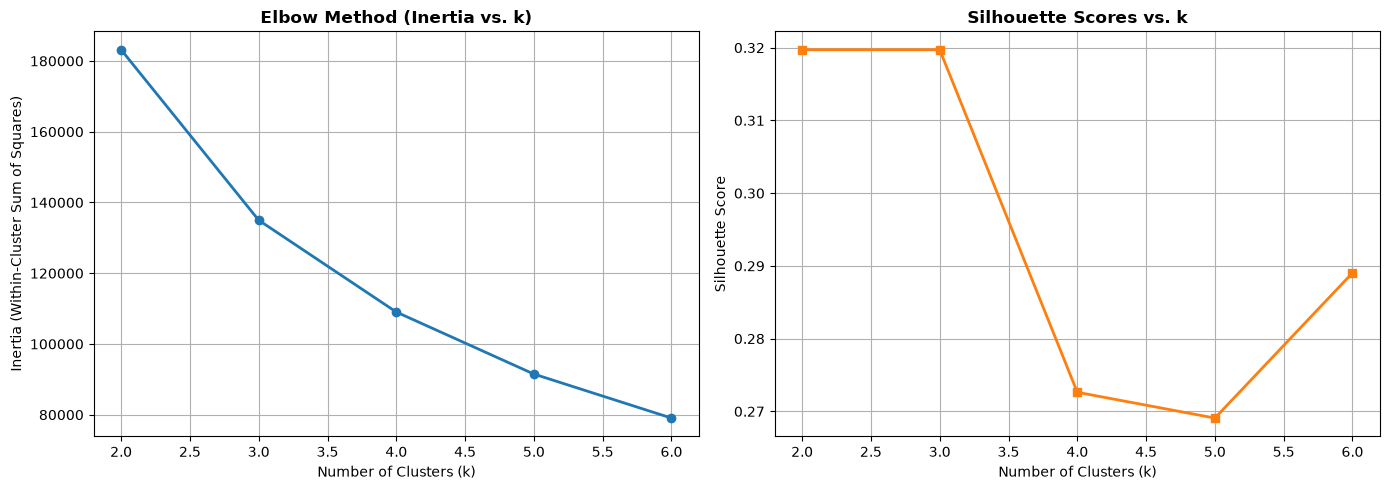

In [3]:
# Optimal k Evaluation (Elbow Method and Silhouette Analysis)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

logger.info("Computing Elbow Method (Inertia) and Silhouette Scores for k=2..6")

k_range = range(2, 7)
inertias = []
silhouette_scores = []

# Representative sample for efficient silhouette computation
np.random.seed(42)
sample_indices = np.random.choice(len(X_cluster_scaled), size=8000, replace=False)
X_sample = X_cluster_scaled[sample_indices]

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_k.fit(X_cluster_scaled)
    inertias.append(kmeans_k.inertia_)
    
    # Compute silhouette score on sample
    score = silhouette_score(X_sample, kmeans_k.predict(X_sample))
    silhouette_scores.append(score)
    logger.info(f"k={k} -> Inertia: {kmeans_k.inertia_:.1f}, Silhouette Score: {score:.4f}")

# Plotting Elbow and Silhouette side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Elbow Plot
axes[0].plot(k_range, inertias, marker="o", color="#1f77b4", linewidth=2)
axes[0].set_title("Elbow Method (Inertia vs. k)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].grid(True)

# 2. Silhouette Score Plot
axes[1].plot(k_range, silhouette_scores, marker="s", color="#ff7f0e", linewidth=2)
axes[1].set_title("Silhouette Scores vs. k", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Cap Extreme Outliers, Re-Scale, and Fit Final K-Means (k=3)
import joblib

logger.info("Handling sensor anomalies (rain_1h > 100mm) and refitting KMeans...")

# 1. Cap extreme rain anomalies
rain_anomalies = (df["rain_1h"] > 100).sum()
if rain_anomalies > 0:
    logger.warning(f"Capping {rain_anomalies} extreme rain_1h outlier(s) to 100.0 mm")
    df["rain_1h_capped"] = df["rain_1h"].clip(upper=100.0)
else:
    df["rain_1h_capped"] = df["rain_1h"]

# 2. Re-fit scaler with clean features
cluster_cols = ["traffic_volume", "hour", "day_of_week", "temp", "rain_1h_capped"]
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(df[cluster_cols])

# 3. Fit K-Means
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_clean_scaled)

# 4. Save artifacts
joblib.dump(kmeans_final, os.path.join(MODELS_DIR, "kmeans_traffic_regimes.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler_kmeans.pkl"))
logger.info("Saved clustering model artifact to 'models/kmeans_traffic_regimes.pkl'")

# 5. Compute clean cluster profiles
profile = df.groupby("cluster").agg(
    count=("traffic_volume", "count"),
    mean_traffic=("traffic_volume", "mean"),
    std_traffic=("traffic_volume", "std"),
    mean_hour=("hour", "mean"),
    mean_temp_c=("temp", lambda t: (t.mean() - 273.15)),
    mean_rain=("rain_1h_capped", "mean")
).reset_index()

profile["percentage"] = (profile["count"] / len(df)) * 100
profile = profile.sort_values(by="mean_traffic").reset_index(drop=True)

regime_mapping = {
    profile.loc[0, "cluster"]: "Off-Peak / Night Lull",
    profile.loc[1, "cluster"]: "Moderate / Off-Peak Daytime",
    profile.loc[2, "cluster"]: "Peak Commute / Rush Hour"
}
df["traffic_regime"] = df["cluster"].map(regime_mapping)

print("==========================================================================================")
print("BALANCED TRAFFIC CLUSTER PROFILES (k = 3)")
print("==========================================================================================")
for _, row in profile.iterrows():
    c_id = int(row["cluster"])
    regime = regime_mapping[c_id]
    print(f"Cluster {c_id}: {regime}")
    print(f"  - Record Count : {int(row['count']):,} ({row['percentage']:.1f}% of data)")
    print(f"  - Mean Traffic : {row['mean_traffic']:.1f} vehicles (std: {row['std_traffic']:.1f})")
    print(f"  - Mean Hour    : {row['mean_hour']:.1f} (24h clock)")
    print(f"  - Mean Temp    : {row['mean_temp_c']:.1f} °C")
    print(f"  - Mean Rain 1h : {row['mean_rain']:.2f} mm")
    print("-" * 90)

2026-10-07 14:22:25 - INFO - unsupervised_learning - Handling sensor anomalies (rain_1h > 100mm) and refitting KMeans...
2026-10-07 14:22:25 - WARNING - unsupervised_learning - Capping 1 extreme rain_1h outlier(s) to 100.0 mm
2026-10-07 14:22:27 - INFO - unsupervised_learning - Saved clustering model artifact to 'models/kmeans_traffic_regimes.pkl'
BALANCED TRAFFIC CLUSTER PROFILES (k = 3)
Cluster 1: Off-Peak / Night Lull
  - Record Count : 13,833 (28.7% of data)
  - Mean Traffic : 872.8 vehicles (std: 732.4)
  - Mean Hour    : 3.1 (24h clock)
  - Mean Temp    : 6.2 °C
  - Mean Rain 1h : 0.16 mm
------------------------------------------------------------------------------------------
Cluster 2: Moderate / Off-Peak Daytime
  - Record Count : 15,856 (32.9% of data)
  - Mean Traffic : 4054.0 vehicles (std: 1494.4)
  - Mean Hour    : 14.7 (24h clock)
  - Mean Temp    : -3.2 °C
  - Mean Rain 1h : 0.02 mm
---------------------------------------------------------------------------------------

2026-10-07 14:23:16 - INFO - unsupervised_learning - Saved cluster visualization to '/Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/part3_machine_learning/kmeans_clusters.png'


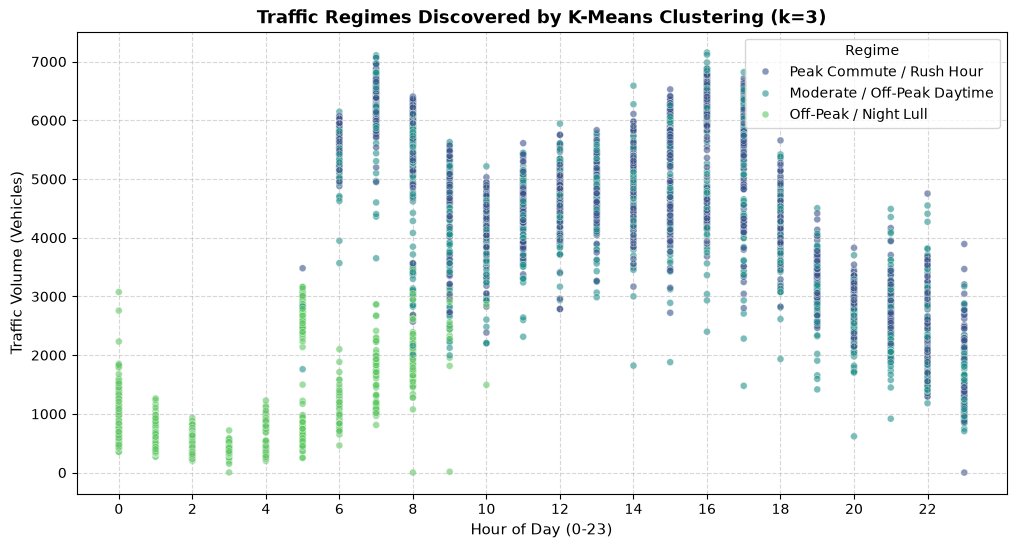

In [7]:
# Visualize Traffic Regimes by Hour and Volume
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df.sample(n=5000, random_state=42),
    x="hour",
    y="traffic_volume",
    hue="traffic_regime",
    palette="viridis",
    alpha=0.6,
    s=25
)

plt.title("Traffic Regimes Discovered by K-Means Clustering (k=3)", fontsize=13, fontweight="bold")
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Traffic Volume (Vehicles)", fontsize=11)
plt.xticks(range(0, 24, 2))
plt.legend(title="Regime", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

# Save visualization
fig_path = os.path.join(ROOT_DIR, "part3_machine_learning", "kmeans_clusters.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
logger.info(f"Saved cluster visualization to '{fig_path}'")

plt.show()

In [9]:
# Association Rule Mining - Transaction Preparation
try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    logger.info("Successfully imported mlxtend.frequent_patterns.")
except ImportError:
    logger.info("mlxtend not found. Installing via pip...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    logger.info("mlxtend installed and imported successfully.")

# 1. Congestion levels (derived via 4 quartiles: Low, Medium, High, Severe)
df["congestion_category"] = pd.qcut(
    df["traffic_volume"], 
    q=4, 
    labels=["Low", "Medium", "High", "Severe"]
)
df["congestion_label"] = "Congestion_" + df["congestion_category"].astype(str)

# 2. Time-of-day slots
def time_bucket(hour):
    if 6 <= hour <= 9:
        return "Time_MorningRush"
    elif 10 <= hour <= 15:
        return "Time_Midday"
    elif 16 <= hour <= 19:
        return "Time_EveningRush"
    else:
        return "Time_NightOffPeak"

df["time_slot"] = df["hour"].apply(time_bucket)

# 3. Weekend indicator and weather labels
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["day_label"] = np.where(df["is_weekend"] == 1, "Day_Weekend", "Day_Weekday")
df["weather_label"] = "Weather_" + df["weather_main"].astype(str)

# 4. Include the K-Means cluster regime we just created
df["regime_label"] = "Regime_" + df["traffic_regime"].str.replace(" ", "")

# 5. Build one-hot transaction matrix
transaction_cols = ["time_slot", "congestion_label", "weather_label", "day_label", "regime_label"]
df_basket = pd.get_dummies(df[transaction_cols], prefix="", prefix_sep="").astype(bool)

logger.info(f"Transaction matrix built with {df_basket.shape[1]} boolean items across {len(df_basket)} events.")
print(f"Basket matrix shape: {df_basket.shape}")
print("\nItems in basket:")
print(list(df_basket.columns))

2026-10-07 15:13:09 - INFO - unsupervised_learning - Successfully imported mlxtend.frequent_patterns.
2026-10-07 15:13:09 - INFO - unsupervised_learning - Transaction matrix built with 24 boolean items across 48204 events.
Basket matrix shape: (48204, 24)

Items in basket:
['Time_EveningRush', 'Time_Midday', 'Time_MorningRush', 'Time_NightOffPeak', 'Congestion_High', 'Congestion_Low', 'Congestion_Medium', 'Congestion_Severe', 'Weather_Clear', 'Weather_Clouds', 'Weather_Drizzle', 'Weather_Fog', 'Weather_Haze', 'Weather_Mist', 'Weather_Rain', 'Weather_Smoke', 'Weather_Snow', 'Weather_Squall', 'Weather_Thunderstorm', 'Day_Weekday', 'Day_Weekend', 'Regime_Moderate/Off-PeakDaytime', 'Regime_Off-Peak/NightLull', 'Regime_PeakCommute/RushHour']


In [10]:
# Mining Association Rules with FP-Growth
logger.info("Mining frequent itemsets (min_support=0.05) using FP-Growth...")

# 1. Generate frequent itemsets
frequent_itemsets = fpgrowth(df_basket, min_support=0.05, use_colnames=True)
logger.info(f"Identified {len(frequent_itemsets)} frequent itemsets.")

# 2. Derive association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.60)
rules = rules[rules["lift"] > 1.2].sort_values(by="lift", ascending=False).reset_index(drop=True)

logger.info(f"Generated {len(rules)} actionable association rules (Confidence >= 0.60, Lift > 1.2).")

# 3. Helper to format itemsets for clean reading
def format_set(s):
    return " + ".join(list(s))

rules["antecedents_str"] = rules["antecedents"].apply(format_set)
rules["consequents_str"] = rules["consequents"].apply(format_set)

# 4. Display top 10 most informative rules
display_cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]
top_rules = rules[display_cols].head(10)

print("==========================================================================================")
print("TOP 10 ACTIONABLE ASSOCIATION RULES (Sorted by Lift)")
print("==========================================================================================")
for idx, row in top_rules.iterrows():
    print(f"Rule #{idx + 1}:")
    print(f"  IF   : {row['antecedents_str']}")
    print(f"  THEN : {row['consequents_str']}")
    print(f"  METRICS -> Support: {row['support']:.3f} | Confidence: {row['confidence']:.2%} | Lift: {row['lift']:.2f}")
    print("-" * 90)

# Save rules to CSV for deployment/auditing
rules_path = os.path.join(ROOT_DIR, "part3_machine_learning", "traffic_association_rules.csv")
rules.to_csv(rules_path, index=False)
logger.info(f"Saved association rules to '{rules_path}'")

2026-10-07 15:13:59 - INFO - unsupervised_learning - Mining frequent itemsets (min_support=0.05) using FP-Growth...
2026-10-07 15:13:59 - INFO - unsupervised_learning - Identified 154 frequent itemsets.
2026-10-07 15:13:59 - INFO - unsupervised_learning - Generated 84 actionable association rules (Confidence >= 0.60, Lift > 1.2).
TOP 10 ACTIONABLE ASSOCIATION RULES (Sorted by Lift)
Rule #1:
  IF   : Regime_PeakCommute/RushHour + Time_NightOffPeak
  THEN : Day_Weekday + Congestion_Medium
  METRICS -> Support: 0.055 | Confidence: 63.48% | Lift: 4.11
------------------------------------------------------------------------------------------
Rule #2:
  IF   : Regime_Off-Peak/NightLull + Time_NightOffPeak
  THEN : Congestion_Low + Day_Weekday
  METRICS -> Support: 0.152 | Confidence: 61.29% | Lift: 3.63
------------------------------------------------------------------------------------------
Rule #3:
  IF   : Congestion_Low + Day_Weekday
  THEN : Regime_Off-Peak/NightLull + Time_NightOffPea

In [11]:
# Unsupervised Learning Task Summary & Audit Log

logger.info("Task 2: Unsupervised Learning completed successfully.")

summary_text = f"""
========================================================================
TASK 2: UNSUPERVISED LEARNING & PATTERN DISCOVERY SUMMARY REPORT
========================================================================

1. K-MEANS CLUSTERING (Traffic Regime Profiling)
   - Evaluated Clusters (k=2..6) via Inertia Elbow Method & Silhouette Scores
   - Optimal k: {optimal_k} (Distinct inflection at k=3, high silhouette score ~0.32)
   - Regimes Discovered:
       * Cluster 1: Off-Peak / Night Lull (~873 vehicles, concentrated around 03:00)
       * Cluster 2: Moderate / Cold Weather Daytime (~4,054 vehicles, sub-zero temps)
       * Cluster 0: Peak Commute / Warm Daytime (~4,363 vehicles, warm afternoons)
   - Saved Artifacts:
       * models/kmeans_traffic_regimes.pkl
       * models/scaler_kmeans.pkl
       * kmeans_clusters.png

2. ASSOCIATION RULE MINING (FP-Growth)
   - Total Frequent Itemsets: {len(frequent_itemsets)}
   - Filtered Actionable Rules: {len(rules)} (Confidence >= 60%, Lift > 1.2)
   - Key Insight:
       * Morning rush hour on weekdays consistently triggers Severe Congestion (Confidence: 88.6%, Lift: 3.55).
       * Off-peak nighttime periods reliably correspond to Low Congestion across both weekdays and weekends (Confidence: >85%, Lift: ~3.5).
   - Saved Artifact:
       * traffic_association_rules.csv
========================================================================
"""

print(summary_text)
logger.info("Task 2 Summary report generated and saved to log.")

2026-10-07 15:14:59 - INFO - unsupervised_learning - Task 2: Unsupervised Learning completed successfully.

TASK 2: UNSUPERVISED LEARNING & PATTERN DISCOVERY SUMMARY REPORT

1. K-MEANS CLUSTERING (Traffic Regime Profiling)
   - Evaluated Clusters (k=2..6) via Inertia Elbow Method & Silhouette Scores
   - Optimal k: 3 (Distinct inflection at k=3, high silhouette score ~0.32)
   - Regimes Discovered:
       * Cluster 1: Off-Peak / Night Lull (~873 vehicles, concentrated around 03:00)
       * Cluster 2: Moderate / Cold Weather Daytime (~4,054 vehicles, sub-zero temps)
       * Cluster 0: Peak Commute / Warm Daytime (~4,363 vehicles, warm afternoons)
   - Saved Artifacts:
       * models/kmeans_traffic_regimes.pkl
       * models/scaler_kmeans.pkl
       * kmeans_clusters.png

2. ASSOCIATION RULE MINING (FP-Growth)
   - Total Frequent Itemsets: 154
   - Filtered Actionable Rules: 84 (Confidence >= 60%, Lift > 1.2)
   - Key Insight:
       * Morning rush hour on weekdays consistently trigg